# 1.7 Données géodésiques GNSS

Ce carnet télécharge des séries temporelles de positions GNSS quotidiennes depuis le [Nevada Geodetic Laboratory](https://geodesy.unr.edu) (NGL) de l'Université du Nevada à Reno. Le NGL traite les données de milliers de stations GNSS permanentes dans le monde entier — les stations françaises comprises — et publie des solutions de position quotidiennes en fichiers texte, un fichier par station.

**Ce que sont les données.** Une station GNSS permanente mesure sa propre position, chaque jour, à quelques millimètres près. La série temporelle enregistre les mouvements du sol : la dérive tectonique régulière des plaques, les séismes (décalages soudains), les glissements lents, et les charges saisonnières d'eau et de neige.

**Référentiel.** Nous utilisons les solutions en **IGS20**, la réalisation actuelle du repère international de référence terrestre adoptée par le Service GNSS international (IGS). Les positions sont exprimées dans ce repère global : les tendances régulières que vous verrez sont les mouvements des plaques.

**Citation.** Pour tout usage des produits NGL, citez : Blewitt, G., Hammond, W. C., & Kreemer, C. (2018). Harnessing the GPS data explosion for interdisciplinary science. *Eos*, 99, [doi:10.1029/2018EO104623](https://doi.org/10.1029/2018EO104623).

🖥️ [**Diapositives du cours — Séance 04 (mer. 7 oct.)**](slides/2026/lec04_meet_the_data.html)

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import pooch

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

## Le format `.tenv3`

Chaque fichier de station à `https://geodesy.unr.edu/gps_timeseries/IGS20/tenv3/IGS20/{STATION}.tenv3` est délimité par des espaces, avec une ligne d'en-tête. Les colonnes comprennent le nom de la station (`site`), la date (`YYMMMDD`), l'année décimale (`yyyy.yyyy`), et les composantes de position scindées en une base entière et une partie variable : `__east(m)`, `_north(m)` et `____up(m)` portent la partie variable des positions est, nord et verticale, en mètres. Les soulignés incongrus font partie des vrais noms de colonnes ; nous inspectons donc l'en-tête après lecture plutôt que de le supposer.

L'édition française tire deux stations françaises de cette archive mondiale : **GRAS** et **BRST**. GRAS est installée sur le plateau de Calern, à Caussols (Alpes-Maritimes), à l'Observatoire de la Côte d'Azur, dans les Préalpes ; en service depuis 1995, intégrée aux réseaux IGS et RENAG (Epos-France), elle porte l'une des plus longues séries GNSS de France métropolitaine. BRST est à Brest (Finistère), voisine du marégraphe de Brest — l'une des plus longues séries de niveau marin au monde ; ses positions servent notamment à séparer le mouvement vertical du sol des variations du niveau de la mer. (L'édition anglaise utilise ici deux stations du nord-ouest des États-Unis, P395 et P563 — même archive, même code.)

## Télécharger avec pooch — et pourquoi pas d'empreinte épinglée ici

La section [1.6](1.6_data_gallery.md) a enseigné le motif : télécharger avec `pooch`, puis épingler la somme de contrôle affichée dans `known_hash`, pour que chaque exécution future vérifie qu'elle a bien reçu les mêmes octets. Ce motif vaut pour les fichiers **figés** — un jeu de données publié, un instantané archivé, le raster Natural Earth du chapitre 2.2.

Ces fichiers NGL sont des **données vivantes** : une nouvelle solution quotidienne s'y ajoute chaque jour, donc l'empreinte du fichier change chaque jour, et une empreinte épinglée aujourd'hui échouerait demain — à juste titre, puisque le fichier a réellement changé. Ici nous passons donc `known_hash=None` et *affichons* le SHA256 de ce que nous avons effectivement reçu. Cette empreinte affichée est votre trace de provenance : copiez-la dans vos notes ou votre journal d'exécution, et l'analyse du jour reste liée à une entrée exacte, même si le téléchargement de demain différera. S'il vous faut des réexécutions identiques au bit près (un article, un rendu noté), figez un instantané — archivez le fichier téléchargé (Zenodo, la *release* de données de votre dépôt) et épinglez l'empreinte de *cette* copie.

Une mise en garde sur le cache : avec `known_hash=None`, pooch réutilise une copie en cache sans interroger le serveur. Supprimez le fichier `.tenv3` de `data/` quand vous voulez les données du jour plutôt que celles du premier passage du carnet.

In [2]:
BASE_URL = "https://geodesy.unr.edu/gps_timeseries/IGS20/tenv3/IGS20/{station}.tenv3"


def fetch_tenv3(station):
    """Fetch an NGL .tenv3 daily position file (cached by pooch) as a DataFrame."""
    path = pooch.retrieve(
        url=BASE_URL.format(station=station),
        known_hash=None,  # living data: NGL appends a new daily solution every day
        fname=f"{station}.tenv3",
        path=DATA_DIR,
        downloader=pooch.HTTPDownloader(timeout=120),
    )
    print(f"{station}.tenv3 sha256:{pooch.file_hash(path)}")
    # whitespace-delimited text with one header line
    return pd.read_csv(path, sep=r"\s+")


df = fetch_tenv3("GRAS")
print(df.columns.tolist())

SHA256 hash of downloaded file: 275ce699c5af7fd95a321d38d2bf44a84b7c19160d41b9aa1de792d6d57ada79
Use this value as the 'known_hash' argument of 'pooch.retrieve' to ensure that the file hasn't changed if it is downloaded again in the future.


GRAS.tenv3 sha256:275ce699c5af7fd95a321d38d2bf44a84b7c19160d41b9aa1de792d6d57ada79
['site', 'YYMMMDD', 'yyyy.yyyy', '__MJD', 'week', 'd', 'reflon', '_e0(m)', '__east(m)', '____n0(m)', '_north(m)', 'u0(m)', '____up(m)', '_ant(m)', 'sig_e(m)', 'sig_n(m)', 'sig_u(m)', '__corr_en', '__corr_eu', '__corr_nu', '_latitude(deg)', '_longitude(deg)', '__height(m)']


In [3]:
df.head()

,site,YYMMMDD,yyyy.yyyy,__MJD,week,d,reflon,_e0(m),__east(m),____n0(m),...,_ant(m),sig_e(m),sig_n(m),sig_u(m),__corr_en,__corr_eu,__corr_nu,_latitude(deg),_longitude(deg),__height(m)
0,GRAS,95FEB22,1995.1431,49770,789,3,6.9,1656,0.678331,4846571,...,0.035,0.000825,0.001035,0.003527,0.009339,0.078377,-0.129457,43.754736,-353.079429,1319.30053
1,GRAS,95FEB23,1995.1458,49771,789,4,6.9,1656,0.683536,4846571,...,0.035,0.000812,0.001023,0.003448,-0.030175,0.093333,-0.159852,43.754736,-353.079429,1319.29376
2,GRAS,95FEB24,1995.1485,49772,789,5,6.9,1656,0.680819,4846571,...,0.035,0.000823,0.001052,0.003491,-0.014224,0.051443,-0.155523,43.754736,-353.079429,1319.30487
3,GRAS,95FEB25,1995.1513,49773,789,6,6.9,1656,0.681039,4846571,...,0.035,0.000815,0.001044,0.003507,-0.025162,0.111291,-0.142687,43.754736,-353.079429,1319.31021
4,GRAS,95FEB26,1995.1540,49774,790,0,6.9,1656,0.680421,4846571,...,0.035,0.000834,0.001036,0.003545,-0.007561,0.087213,-0.153935,43.754736,-353.079429,1319.31316


## Déplacement relatif

Les coordonnées absolues sont de grands nombres ; ce qui nous intéresse est le mouvement. Nous soustrayons de chaque composante la première solution quotidienne : chaque série démarre à zéro et montre le déplacement, en mètres, depuis la première observation. Nous gardons l'année décimale comme axe du temps.

In [4]:
def to_relative(df):
    """Return decimal year and east/north/up displacement (m) relative to the first epoch."""
    return pd.DataFrame(
        {
            "decimal_year": df["yyyy.yyyy"],
            "east_m": df["__east(m)"] - df["__east(m)"].iloc[0],
            "north_m": df["_north(m)"] - df["_north(m)"].iloc[0],
            "up_m": df["____up(m)"] - df["____up(m)"].iloc[0],
        }
    )


rel_p395 = to_relative(df)
rel_p395.describe()

,decimal_year,east_m,north_m,up_m
count,10837.000000,10837.000000,10837.000000,10837.000000
mean,2011.344139,0.333975,0.260438,0.011262
std,8.904234,0.184216,0.144461,0.008491
min,1995.143100,-0.007606,-0.007133,-0.303682
25%,2003.696100,0.173510,0.133932,0.006631
50%,2011.542800,0.340692,0.266040,0.011158
75%,2019.003400,0.489589,0.384550,0.015879
max,2026.505100,0.654158,0.506043,0.097171


In [5]:
# download both stations and save the relative positions to ./data/
stations = ["GRAS", "BRST"]
series = {}
for station in stations:
    rel = to_relative(fetch_tenv3(station))
    outfile = DATA_DIR / f"gps_{station}_relative_position.csv"
    rel.to_csv(outfile, index=False)
    series[station] = rel
    print(f"{station}: {len(rel)} daily solutions saved to {outfile}")

GRAS.tenv3 sha256:275ce699c5af7fd95a321d38d2bf44a84b7c19160d41b9aa1de792d6d57ada79
GRAS: 10837 daily solutions saved to data/gps_GRAS_relative_position.csv


SHA256 hash of downloaded file: bc00de3a387dded96f6c5fe8b60cc849a7a412179f59856f3c3d2463aa0dee9e
Use this value as the 'known_hash' argument of 'pooch.retrieve' to ensure that the file hasn't changed if it is downloaded again in the future.


BRST.tenv3 sha256:bc00de3a387dded96f6c5fe8b60cc849a7a412179f59856f3c3d2463aa0dee9e
BRST: 9228 daily solutions saved to data/gps_BRST_relative_position.csv


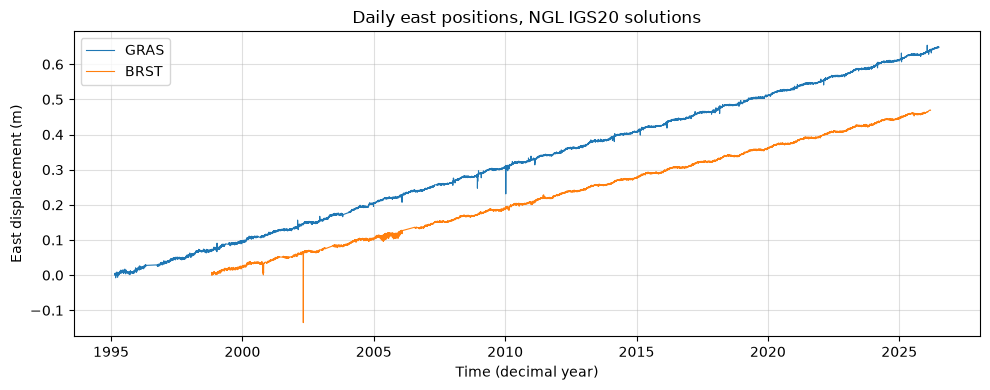

In [6]:
fig, ax = plt.subplots(figsize=(10, 4))
for station, rel in series.items():
    ax.plot(rel["decimal_year"], rel["east_m"], lw=0.8, label=station)
ax.set_xlabel("Time (decimal year)")
ax.set_ylabel("East displacement (m)")
ax.set_title("Daily east positions, NGL IGS20 solutions")
ax.grid(alpha=0.4)
ax.legend()
plt.tight_layout()
plt.show()

Sur la figure, l'axe vertical *East displacement (m)* est le déplacement vers l'est en mètres, et l'axe horizontal *Time (decimal year)* l'année décimale ; les légendes des figures restent en anglais dans toute l'édition française.

Les composantes est montrent un mouvement régulier, quasi linéaire, d'environ 2 cm/an vers l'est : la dérive de la plaque eurasienne, mesurée directement (un ajustement linéaire donne environ 21 mm/an à GRAS et 17 mm/an à BRST). Les deux stations, distantes de près de 1 000 km, dérivent ensemble avec l'Eurasie stable ; l'écart de quelques millimètres par an entre elles tient d'abord à la géométrie de la rotation de plaque — sur une plaque rigide, la vitesse varie avec la position —, la déformation interne de la France métropolitaine restant inférieure au millimètre par an. Regardez de près et vous verrez aussi des ondulations saisonnières (charges d'eau et de neige) et, selon la station et la période, de petits décalages dus à des changements de matériel. À Brest, la composante verticale a son propre intérêt : c'est le mouvement du sol qu'il faut connaître pour interpréter le marégraphe voisin. Dans les chapitres suivants, ce type de série alimente les exercices d'estimation de tendance, de décomposition saisonnière et de prévision.

Les fichiers CSV enregistrés dans `./data/` ne contiennent que l'année décimale et les trois composantes de déplacement, prêts à être réutilisés.

**Crédit des données :** Nevada Geodetic Laboratory (Blewitt et al., 2018, doi:10.1029/2018EO104623). Les données sont librement distribuées ; citez le NGL dans tout ce que vous publierez à partir d'elles.